# Growth of Complexity: Search and Sort

**Motivating question:** Why do some algorithms still feel effortless as data grows, while others suddenly become unusable?

**Learning goals**
- connect the idea of input size `n` to concrete list-processing tasks
- recognize the visual shape of common growth laws
- compare theoretical operation counts with measured runtime
- use search and sorting to see why preprocessing can change the whole story

*This notebook accompanies Lecture 03 on computational complexity. It is designed for live demo and self-study.*


In [1]:
from pathlib import Path
import sys
import math

# The notebook may be launched from the lecture folder or from the repo root.
# We walk upward until we find the shared helper module.
ROOT = Path.cwd().resolve()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / 'utilities' / 'complexity_utils.py').exists():
        ROOT = candidate
        break
else:
    raise RuntimeError('Could not locate utilities/complexity_utils.py')

if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown

from utilities.complexity_utils import (
    display_wrapped,
    COLORS,
    instructor_prompt,
    lecture_figure,
    markdown_box,
    plot_binary_search_demo,
    plot_insertion_sort_passes,
    plot_linear_search_demo,
    plot_merge_sort_decomposition,
    plot_preprocessing_workflow,
    setup_lecture_style,
    time_size_series,
)

setup_lecture_style()
rng = np.random.default_rng(7)
pd.options.display.float_format = lambda value: f'{value:,.4f}'


This notebook follows the shared Lecture 03 visual rhythm: a motivating question, a small model, one dominant visual, a compact comparison, and a short takeaway.

This notebook opens the Lecture 03 sequence. It establishes the visual language for the series: start from a motivating question, use one dominant visual per section, and connect asymptotic growth to small measured experiments without confusing the two.

## 1. What does growth mean?

In this notebook, `n` will usually mean the **number of elements in a list**. That is a natural input measure for search and sorting.

The larger lesson is broader: complexity always depends on how we measure the input. For bit strings, graphs, matrices, or quantum states, the right notion of `n` may be different.


We begin with the simplest visual question: if n grows, which formulas stay manageable and which separate rapidly? The model is intentionally small because the lecture goal is to train the eye before moving to concrete algorithms.

,n,log2(n),n log2(n),n^2,2^n
0,2,1.0000,2.0000,4,4
1,4,2.0000,8.0000,16,16
2,6,2.5850,15.5098,36,64
3,10,3.3219,33.2193,100,1024
4,14,3.8074,53.3030,196,16384
5,18,4.1699,75.0587,324,262144
6,20,4.3219,86.4386,400,1048576


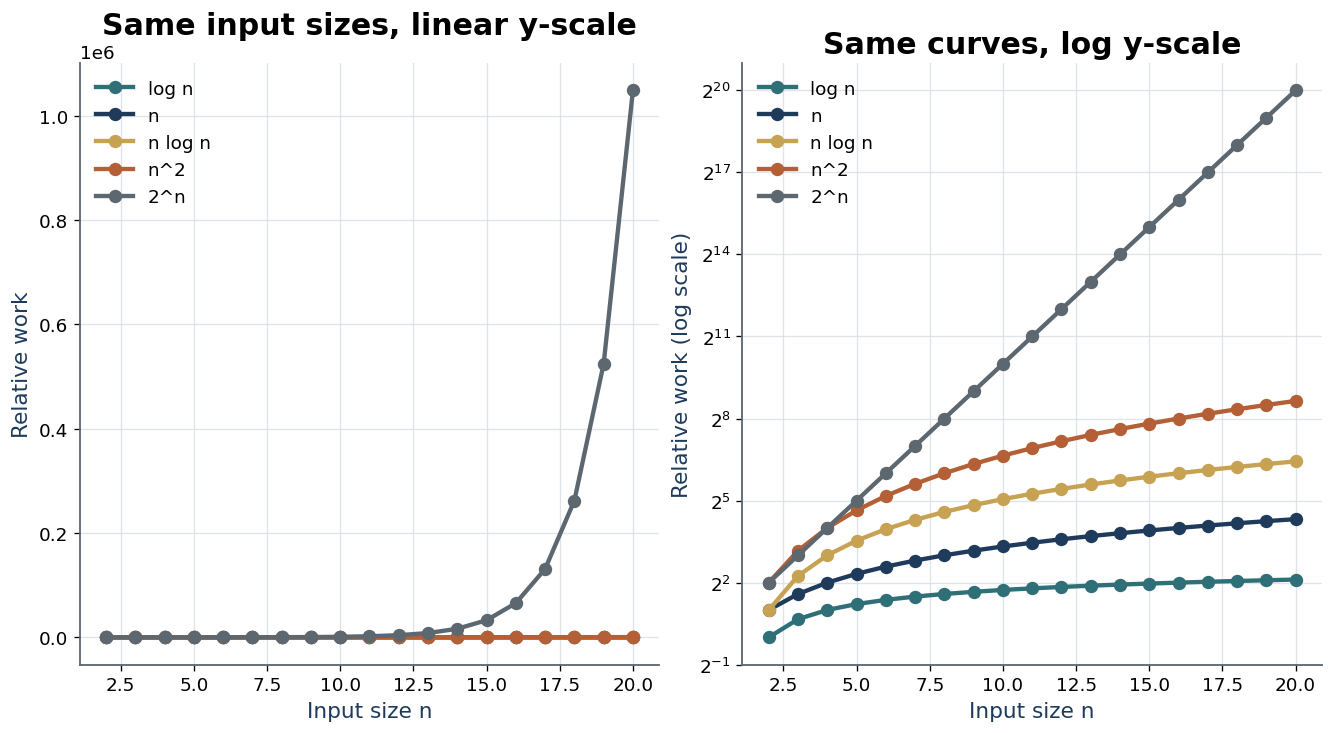

In [2]:
# Here n means "list length". We keep n fairly small in the table so the
# values stay readable during live lecture, even though the point is about
# what happens as n continues to grow.
n = np.arange(2, 21)
growth_df = pd.DataFrame(
    {
        'n': n,
        'log2(n)': np.log2(n),
        'n log2(n)': n * np.log2(n),
        'n^2': n**2,
        '2^n': 2**n,
    }
)

display_wrapped(growth_df.iloc[[0, 2, 4, 8, 12, 16, 18]].reset_index(drop=True))

fig, axes = lecture_figure(kind='wide', ncols=2)

# The left panel gives the immediate visual shock: exponential growth
# quickly dominates the same input-size range.
axes[0].plot(n, np.log2(n), marker='o', label='log n', color=COLORS['teal'])
axes[0].plot(n, n, marker='o', label='n', color=COLORS['navy'])
axes[0].plot(n, n * np.log2(n), marker='o', label='n log n', color=COLORS['gold'])
axes[0].plot(n, n**2, marker='o', label='n^2', color=COLORS['rust'])
axes[0].plot(n, 2**n, marker='o', label='2^n', color=COLORS['gray'])
axes[0].set_title('Same input sizes, linear y-scale')
axes[0].set_xlabel('Input size n')
axes[0].set_ylabel('Relative work')
axes[0].legend(loc='upper left')

# The right panel is not a different experiment. It is the same data on a
# log y-axis, which makes slower-growing curves easier to compare.
axes[1].plot(n, np.log2(n), marker='o', label='log n', color=COLORS['teal'])
axes[1].plot(n, n, marker='o', label='n', color=COLORS['navy'])
axes[1].plot(n, n * np.log2(n), marker='o', label='n log n', color=COLORS['gold'])
axes[1].plot(n, n**2, marker='o', label='n^2', color=COLORS['rust'])
axes[1].plot(n, 2**n, marker='o', label='2^n', color=COLORS['gray'])
axes[1].set_yscale('log', base=2)
axes[1].set_title('Same curves, log y-scale')
axes[1].set_xlabel('Input size n')
axes[1].set_ylabel('Relative work (log scale)')
axes[1].legend(loc='upper left')

plt.show()


On the left, exponential growth quickly overwhelms everything else. On the right, the log-scaled axis lets us see that `n`, `n log n`, and `n^2` are also genuinely different, even if they all looked small for tiny inputs.


In [3]:
display_wrapped(Markdown(markdown_box(
    'Tiny differences in growth law become dramatic once n gets large. Choosing the right algorithm is often more important than shaving a constant factor.'
)))

display_wrapped(Markdown(instructor_prompt(
    'Which curve would you tolerate for n = 10, for n = 1,000, and for n = 1,000,000? '
)))


> **Takeaway:**
> Tiny differences in growth law become dramatic once n gets large. Choosing the right algorithm is often more important than shaving a constant factor.

> **Instructor Prompt:**
> Which curve would you tolerate for n = 10, for n = 1,000, and for n = 1,000,000?

## 2. Search as first intuition

Searching is a good first example because the task is simple: find a target value in a list.

We will compare two ideas:
- **linear search** scans one element after another
- **binary search** repeatedly cuts the remaining search interval in half

Binary search is much faster in principle, but it only works on **sorted** data.


Search is the first concrete place where scaling intuition becomes operational. We will compare operation counts first, then small measured timings, so students can separate mathematical growth from machine-dependent constants.

In [4]:
def linear_search(data, target, *, count_ops=False):
    """Scan the list from left to right until target is found.

    Parameters
    ----------
    data:
        The list being searched.
    target:
        The value we want to find.
    count_ops:
        If True, also return the number of equality comparisons made.

    Returns
    -------
    index or (index, comparisons)
        index is the location of target, or -1 if target is absent.
        comparisons counts how many values were inspected.
    """
    comparisons = 0
    for index, value in enumerate(data):
        # index marks the current position in the list.
        # value is the item stored at that position.
        comparisons += 1
        if value == target:
            return (index, comparisons) if count_ops else index
    return (-1, comparisons) if count_ops else -1


assert linear_search([3, 5, 8, 12, 14, 18, 21, 27], 18) == 5


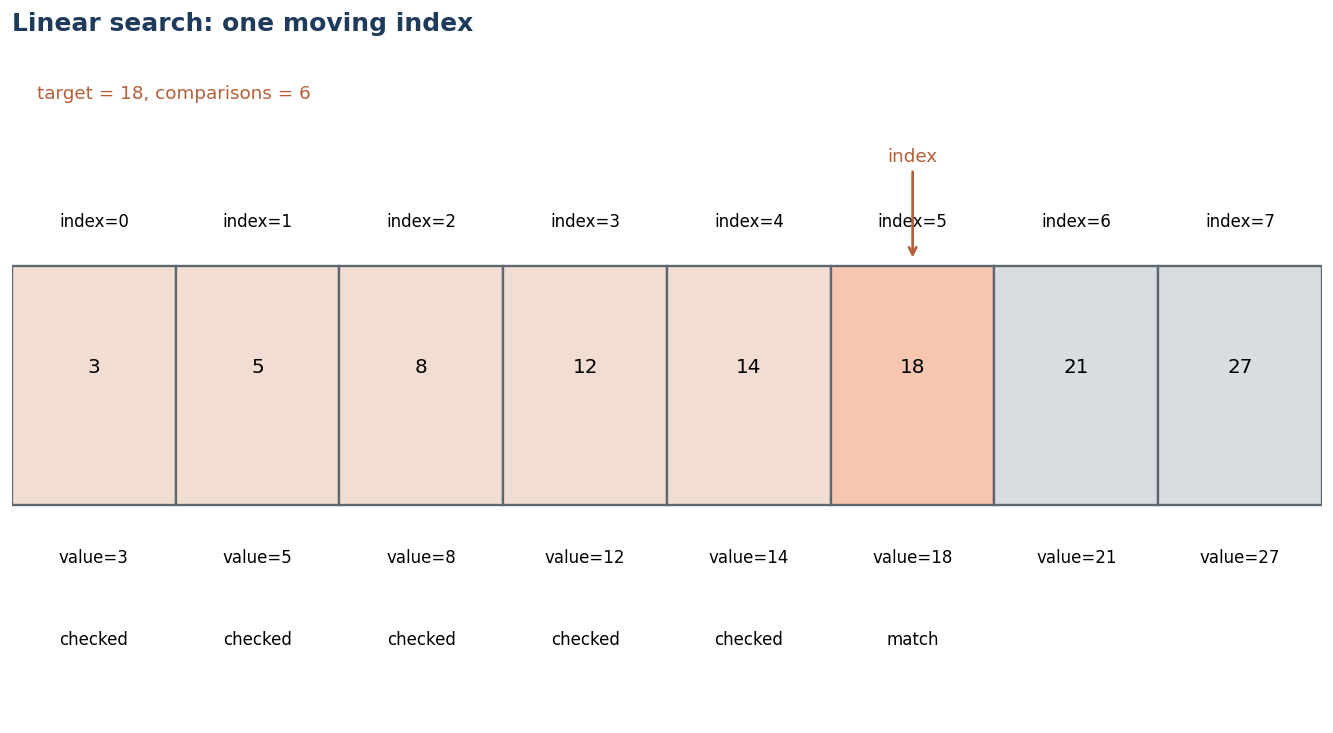

In [5]:
demo_search_data = [3, 5, 8, 12, 14, 18, 21, 27]
target = 18

plot_linear_search_demo(
    demo_search_data,
    target,
    title='Linear search: one moving index',
)
plt.show()


In [6]:
def binary_search(data, target, *, count_ops=False):
    """Search a sorted list by repeatedly halving the active interval.

    left and right mark the current inclusive search window.
    mid is the position inspected in the middle of that window.
    """
    left = 0
    right = len(data) - 1
    comparisons = 0

    while left <= right:
        mid = (left + right) // 2
        comparisons += 1

        if data[mid] == target:
            return (mid, comparisons) if count_ops else mid

        # If the midpoint value is too small, the target can only be on the right.
        if data[mid] < target:
            left = mid + 1
        else:
            right = mid - 1

    return (-1, comparisons) if count_ops else -1


assert binary_search([3, 5, 8, 12, 14, 18, 21, 27], 18) == 5


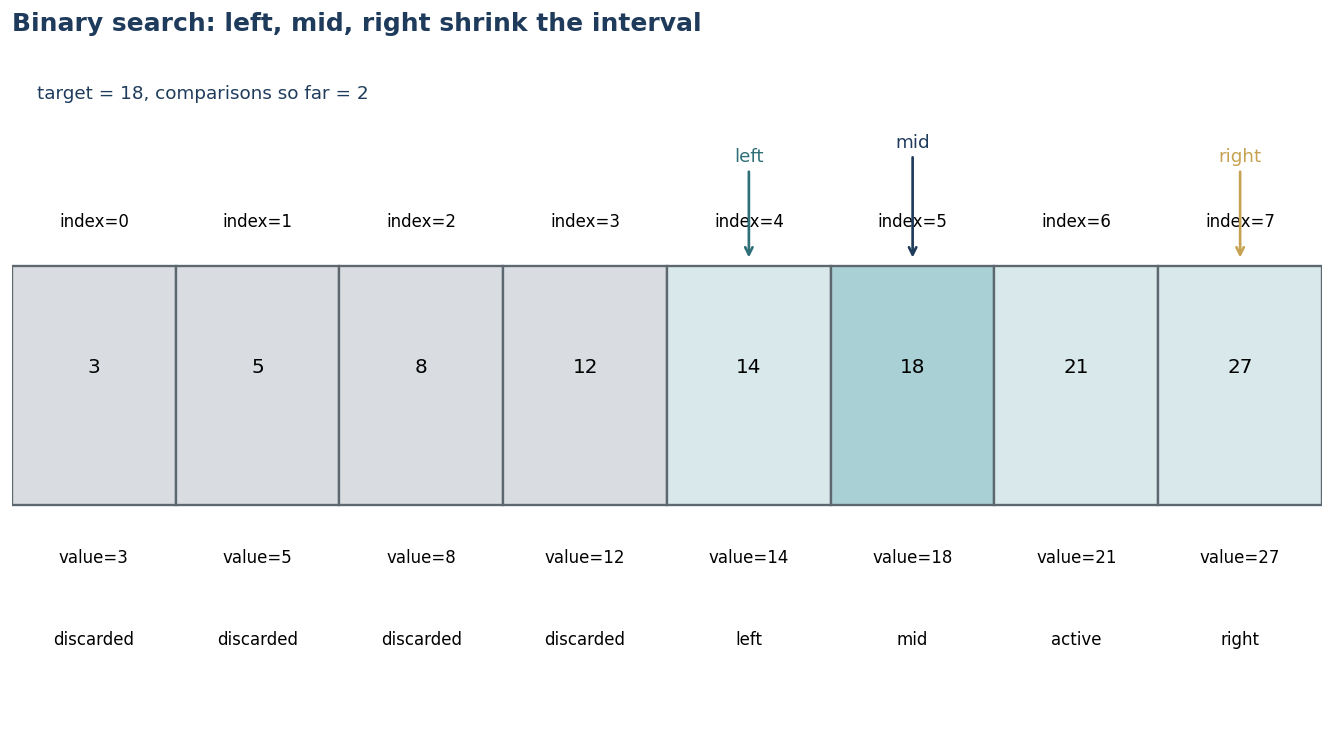

In [7]:
demo_search_data = [3, 5, 8, 12, 14, 18, 21, 27]
target = 18

plot_binary_search_demo(
    demo_search_data,
    target,
    title='Binary search: left, mid, right shrink the interval',
)
plt.show()


The two search diagrams now stand on their own: linear search highlights one moving `index`, while binary search highlights the shrinking interval described by `left`, `mid`, and `right`.


,n,linear search comparisons,binary search comparisons,linear mean ms,binary mean ms
0,500,500,8,0.0157,0.0010
1,2000,2000,10,0.0687,0.0010
2,8000,8000,12,0.2723,0.0014
3,32000,32000,14,1.1719,0.0013
4,128000,128000,16,4.3157,0.0014
5,512000,512000,18,17.5895,0.0019


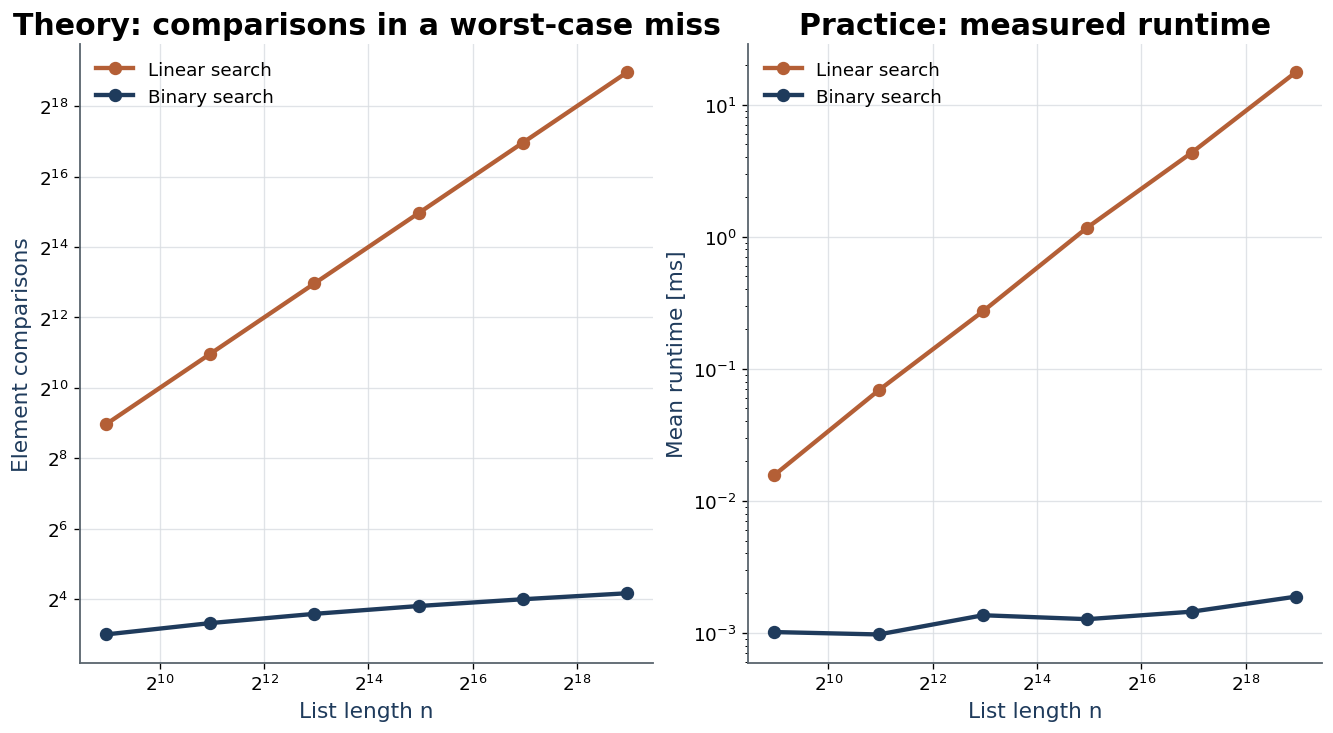

In [8]:
# We count operations on worst-case misses because the pattern is very clean:
# both algorithms must fully commit to their search strategy.
search_sizes = np.array([500, 2_000, 8_000, 32_000, 128_000, 512_000])
sorted_search_data = {int(size): list(range(int(size))) for size in search_sizes}
missing_target = -1

def timed_linear_search(size):
    """Time linear search on a list of the requested size."""
    return linear_search(sorted_search_data[int(size)], missing_target)

def timed_binary_search(size):
    """Time binary search on the same kind of data."""
    return binary_search(sorted_search_data[int(size)], missing_target)

search_story_rows = []
for size in search_sizes:
    _, linear_ops = linear_search(sorted_search_data[int(size)], missing_target, count_ops=True)
    _, binary_ops = binary_search(sorted_search_data[int(size)], missing_target, count_ops=True)
    search_story_rows.append(
        {
            'n': int(size),
            'linear search comparisons': linear_ops,
            'binary search comparisons': binary_ops,
        }
    )
search_story_df = pd.DataFrame(search_story_rows)

# Binary search is so fast here that we repeat it more times to get a stable mean.
linear_search_timing = time_size_series(timed_linear_search, search_sizes, repeat=7, warmup=1)
binary_search_timing = time_size_series(timed_binary_search, search_sizes, repeat=31, warmup=5)

search_story_df['linear mean ms'] = linear_search_timing['mean_s'] * 1_000
search_story_df['binary mean ms'] = binary_search_timing['mean_s'] * 1_000
display_wrapped(search_story_df)

fig, axes = lecture_figure(kind='wide', ncols=2)

axes[0].plot(
    search_story_df['n'],
    search_story_df['linear search comparisons'],
    marker='o',
    label='Linear search',
    color=COLORS['rust'],
)
axes[0].plot(
    search_story_df['n'],
    search_story_df['binary search comparisons'],
    marker='o',
    label='Binary search',
    color=COLORS['navy'],
)
axes[0].set_xscale('log', base=2)
axes[0].set_yscale('log', base=2)
axes[0].set_title('Theory: comparisons in a worst-case miss')
axes[0].set_xlabel('List length n')
axes[0].set_ylabel('Element comparisons')
axes[0].legend(loc='upper left')

axes[1].plot(
    search_story_df['n'],
    search_story_df['linear mean ms'],
    marker='o',
    label='Linear search',
    color=COLORS['rust'],
)
axes[1].plot(
    search_story_df['n'],
    search_story_df['binary mean ms'],
    marker='o',
    label='Binary search',
    color=COLORS['navy'],
)
axes[1].set_xscale('log', base=2)
axes[1].set_yscale('log', base=10)
axes[1].set_title('Practice: measured runtime')
axes[1].set_xlabel('List length n')
axes[1].set_ylabel('Mean runtime [ms]')
axes[1].legend(loc='upper left')

plt.show()


The theoretical picture is clean: linear search grows in proportion to `n`, while binary search grows in proportion to `log n`.

The timing picture tells the same story, but with real-world caveats: Python overhead, cache effects, and measurement noise all matter. Timings help us estimate practical cost; operation counts help us explain **why** the trend appears.


In [9]:
display_wrapped(Markdown(markdown_box(
    'If the data is already sorted, binary search changes the scaling story completely: halving the remaining interval beats scanning every element.'
)))

display_wrapped(Markdown(instructor_prompt(
    'Ask whether binary search is always better. Students should notice the hidden assumption: the data must already be sorted.'
)))


> **Takeaway:**
> If the data is already sorted, binary search changes the scaling story completely: halving the remaining interval beats scanning every element.

> **Instructor Prompt:**
> Ask whether binary search is always better. Students should notice the hidden assumption: the data must already be sorted.

## 3. Sorting as a scaling lesson

Sorting is richer than search because the algorithm has to reorganize the whole list.

We will compare:
- **insertion sort**, a simple `O(n^2)` method that is easy to explain
- **merge sort**, a classic `O(n log n)` divide-and-conquer method


Sorting makes the difference sharper because two algorithms solve the same task while organizing work very differently. The implementations here stay educational on purpose, so the visual story remains readable during live lecture.

In [10]:
def insertion_sort(values):
    """Sort by growing a sorted prefix one position at a time.

    i marks the first element not yet inserted into the sorted prefix.
    key stores the element currently being inserted.
    j walks left through the sorted prefix while larger values are shifted.
    """
    data = list(values)
    comparisons = 0

    for i in range(1, len(data)):
        # Treat data[:i] as the sorted prefix built so far.
        key = data[i]
        j = i - 1

        while j >= 0:
            # Compare key against the prefix from right to left.
            comparisons += 1
            if data[j] > key:
                # Shift larger values one step to the right to open a slot.
                data[j + 1] = data[j]
                j -= 1
            else:
                # Stop once key has found the correct position.
                break

        # Insert key into the gap left behind by the shifts.
        data[j + 1] = key
    return data, comparisons


sample = rng.integers(0, 50, size=12).tolist()
assert insertion_sort(sample)[0] == sorted(sample)


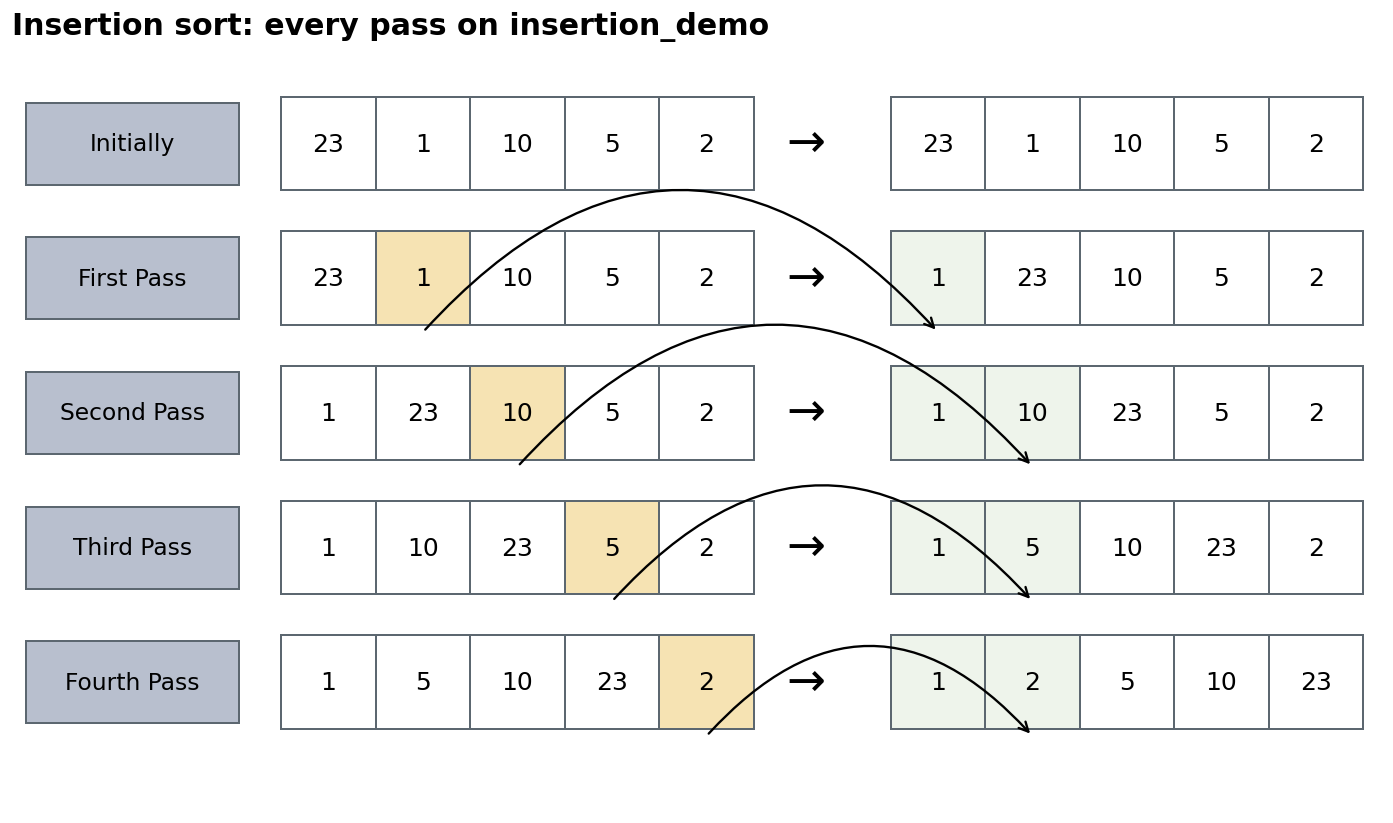

In [11]:
insertion_demo = [23, 1, 10, 5, 2]

plot_insertion_sort_passes(
    insertion_demo,
    title='Insertion sort: every pass on insertion_demo',
)
plt.show()


In [12]:
def merge_sort(values):
    """Sort by recursively splitting the list, then merging sorted halves.

    left and right are the sorted sublists produced by recursion.
    i and j track the next unread positions in those sublists.
    merged stores the output built so far.
    """
    data = list(values)
    if len(data) <= 1:
        # A list of length 0 or 1 is already sorted.
        return data, 0

    # Split the current problem into two smaller sorting problems.
    middle = len(data) // 2
    left, left_comparisons = merge_sort(data[:middle])
    right, right_comparisons = merge_sort(data[middle:])

    # Merge the two sorted halves back into one sorted output list.
    merged = []
    i = 0
    j = 0
    comparisons = left_comparisons + right_comparisons

    while i < len(left) and j < len(right):
        # Compare the next unread value from each half.
        comparisons += 1
        if left[i] <= right[j]:
            # Take the smaller value and advance that pointer.
            merged.append(left[i])
            i += 1
        else:
            merged.append(right[j])
            j += 1

    # One half may still contain leftover values; append them in order.
    merged.extend(left[i:])
    merged.extend(right[j:])
    return merged, comparisons


sample = rng.integers(0, 50, size=12).tolist()
assert merge_sort(sample)[0] == sorted(sample)


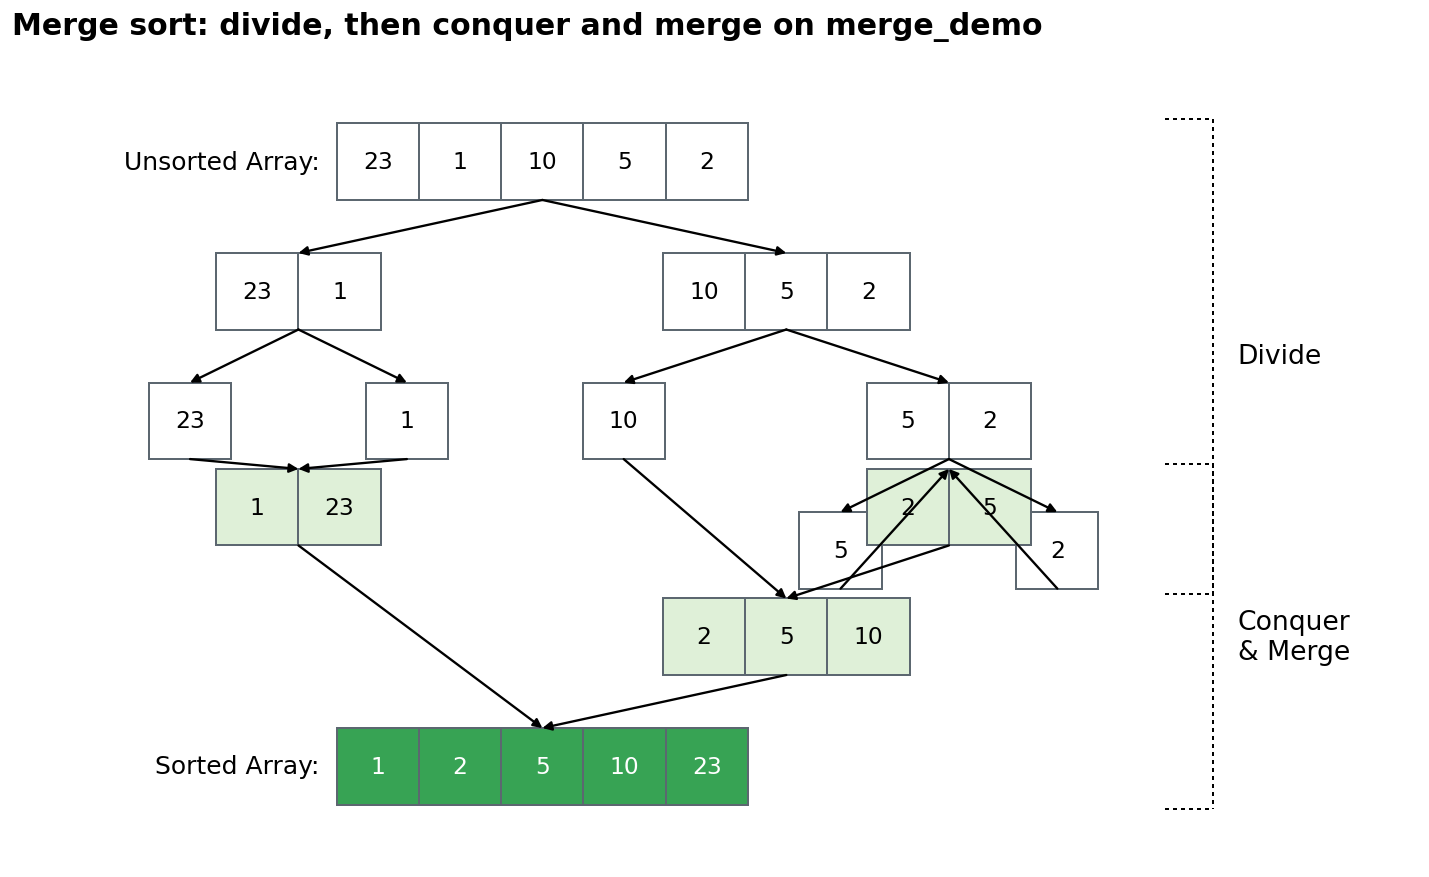

In [13]:
merge_demo = [23, 1, 10, 5, 2]

plot_merge_sort_decomposition(
    merge_demo,
    title='Merge sort: divide, then conquer and merge on merge_demo',
)
plt.show()


The sorting visuals now separate the two ideas cleanly: insertion sort shows every pass on one array, while merge sort shows the full recursive split-and-merge structure for the same example.


,n,insertion sort comparisons,merge sort comparisons,insertion mean ms,merge mean ms
0,32,496,80,0.0177,0.0287
1,64,2016,192,0.0658,0.0599
2,128,8128,448,0.2303,0.1329
3,256,32640,1024,1.0062,0.2878
4,512,130816,2304,4.0939,0.6326
5,1024,523776,5120,16.7479,1.3871
6,2048,2096128,11264,68.9404,2.9888


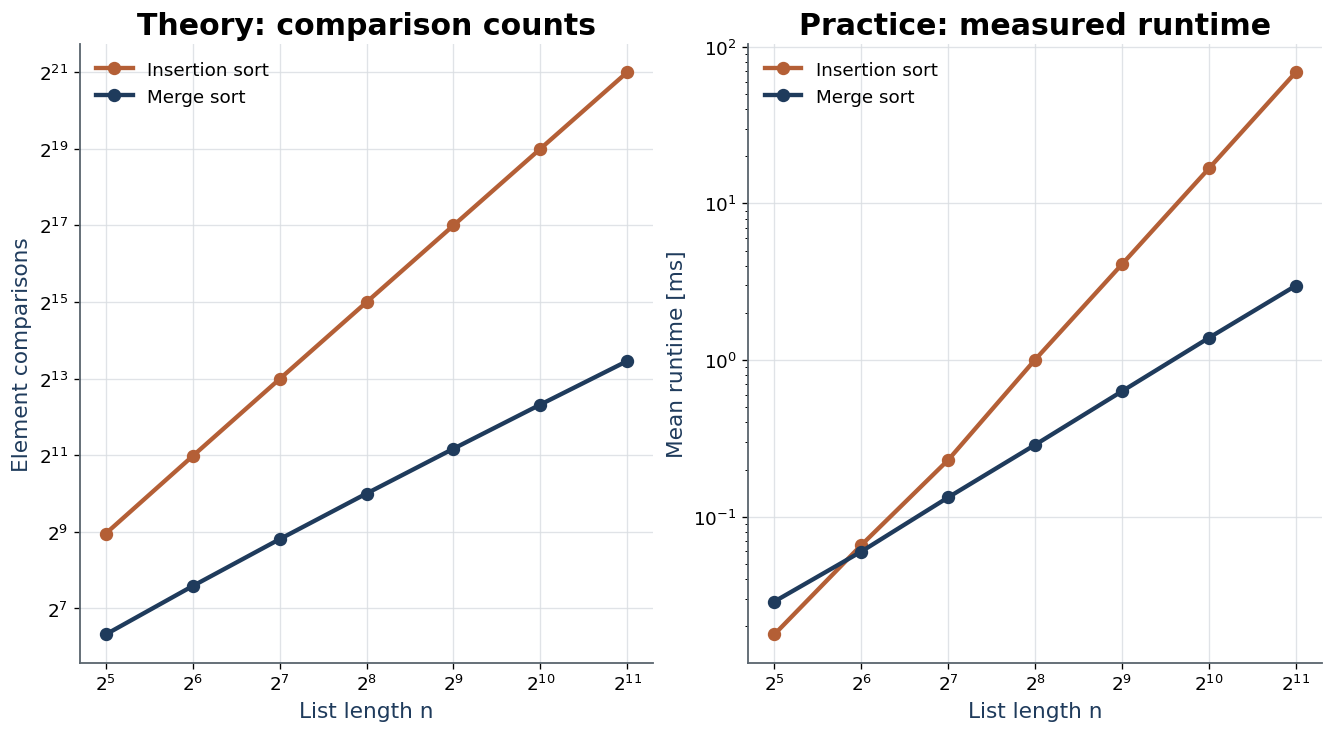

In [14]:
# Reversed input gives insertion sort a very clear worst-case comparison count.
sort_sizes = np.array([32, 64, 128, 256, 512, 1_024, 2_048])
sort_inputs = {
    int(size): rng.integers(0, 10 * int(size), size=int(size)).tolist()
    for size in sort_sizes
}

def timed_insertion_sort(size):
    """Time insertion sort on one fixed random list for this size."""
    return insertion_sort(sort_inputs[int(size)])[0]

def timed_merge_sort(size):
    """Time merge sort on the same input family."""
    return merge_sort(sort_inputs[int(size)])[0]

sort_story_rows = []
for size in sort_sizes:
    reversed_data = list(range(int(size), 0, -1))
    _, insertion_comparisons = insertion_sort(reversed_data)
    _, merge_comparisons = merge_sort(reversed_data)
    sort_story_rows.append(
        {
            'n': int(size),
            'insertion sort comparisons': insertion_comparisons,
            'merge sort comparisons': merge_comparisons,
        }
    )
sort_story_df = pd.DataFrame(sort_story_rows)

insertion_timing = time_size_series(timed_insertion_sort, sort_sizes, repeat=3, warmup=1)
merge_timing = time_size_series(timed_merge_sort, sort_sizes, repeat=5, warmup=1)

sort_story_df['insertion mean ms'] = insertion_timing['mean_s'] * 1_000
sort_story_df['merge mean ms'] = merge_timing['mean_s'] * 1_000
display_wrapped(sort_story_df)

fig, axes = lecture_figure(kind='wide', ncols=2)

axes[0].plot(
    sort_story_df['n'],
    sort_story_df['insertion sort comparisons'],
    marker='o',
    label='Insertion sort',
    color=COLORS['rust'],
)
axes[0].plot(
    sort_story_df['n'],
    sort_story_df['merge sort comparisons'],
    marker='o',
    label='Merge sort',
    color=COLORS['navy'],
)
axes[0].set_xscale('log', base=2)
axes[0].set_yscale('log', base=2)
axes[0].set_title('Theory: comparison counts')
axes[0].set_xlabel('List length n')
axes[0].set_ylabel('Element comparisons')
axes[0].legend(loc='upper left')

axes[1].plot(
    sort_story_df['n'],
    sort_story_df['insertion mean ms'],
    marker='o',
    label='Insertion sort',
    color=COLORS['rust'],
)
axes[1].plot(
    sort_story_df['n'],
    sort_story_df['merge mean ms'],
    marker='o',
    label='Merge sort',
    color=COLORS['navy'],
)
axes[1].set_xscale('log', base=2)
axes[1].set_yscale('log', base=10)
axes[1].set_title('Practice: measured runtime')
axes[1].set_xlabel('List length n')
axes[1].set_ylabel('Mean runtime [ms]')
axes[1].legend(loc='upper left')

plt.show()


Both sorts solve the same problem, but they do not scale the same way. The simple algorithm is attractive on the board because it is easy to read. The more efficient algorithm wins as soon as the list becomes moderately large.


In [20]:
display_wrapped(Markdown(markdown_box(
    'Sorting is where asymptotic language becomes concrete: an O(n^2) method can look harmless on 32 items and painful on 2,048.'
)))

display_wrapped(Markdown(instructor_prompt(
    'Whether the faster algorithm would still be worth it for 5 elements. This opens the door to constants, simplicity, and real engineering tradeoffs.'
)))


> **Takeaway:**
> Sorting is where asymptotic language becomes concrete: an O(n^2) method can look harmless on 32 items and painful on 2,048.

> **Instructor Prompt:**
> Whether the faster algorithm would still be worth it for 5 elements. This opens the door to constants, simplicity, and real engineering tradeoffs.

## 4. Why preprocessing matters

Binary search is fast **after** the data is sorted. That means the full system-level question is not just
"Which search is faster?" but rather
"What is the total cost of preparing the data and then answering many queries?"


Preprocessing changes the system-level question. An expensive setup step may still be the right decision if it unlocks much cheaper repeated queries later on.

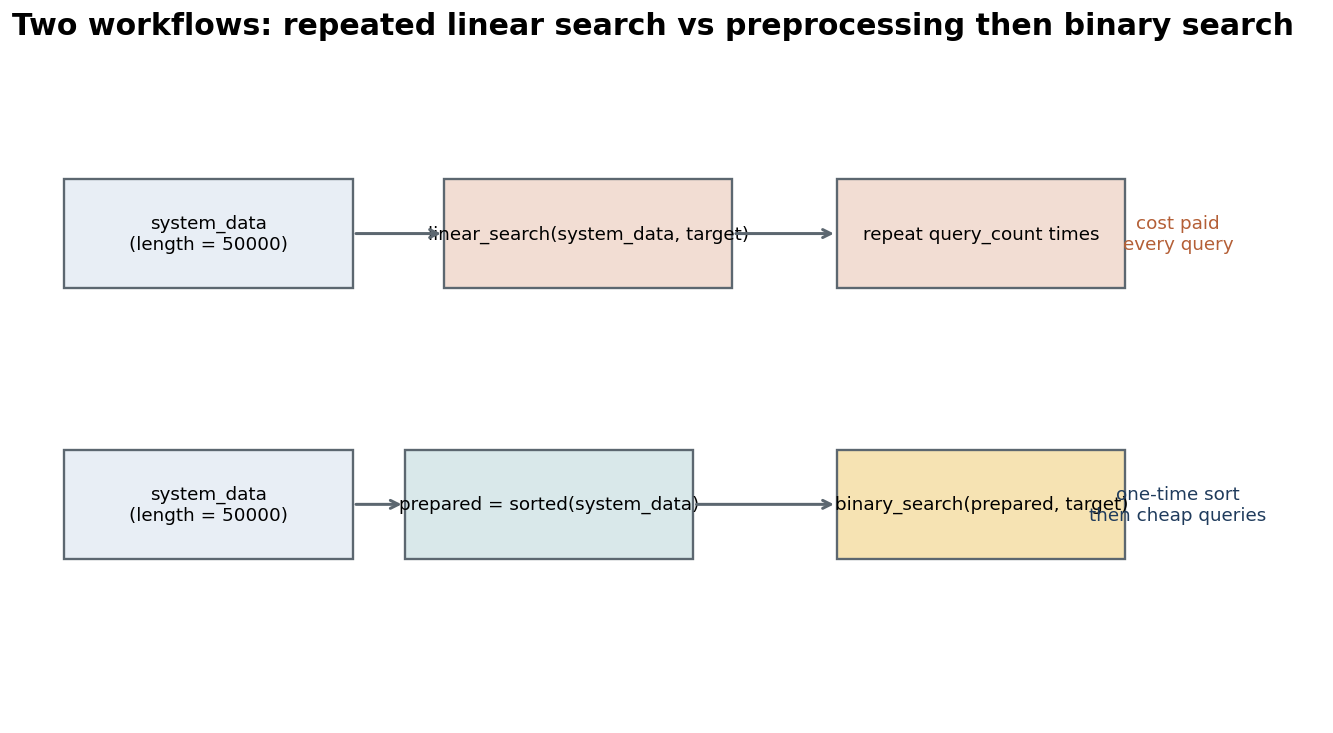

In [16]:
system_n = 50_000
query_counts = np.array([1, 2, 4, 8, 16, 32, 64, 128])

plot_preprocessing_workflow(system_n)
plt.show()


,queries,linear total comparisons,sort once + binary comparisons,linear mean ms,sort once + binary mean ms
0,1,50000,"780,498.0237",1.7393,4.2982
1,2,100000,"780,514.0237",3.4410,4.2752
2,4,200000,"780,546.0237",6.5913,4.3107
3,8,400000,"780,610.0237",13.8106,4.2635
4,16,800000,"780,738.0237",26.6806,4.2600
5,32,1600000,"780,994.0237",51.7908,4.3006
6,64,3200000,"781,506.0237",106.2259,4.3657
7,128,6400000,"782,530.0237",229.7679,4.4184


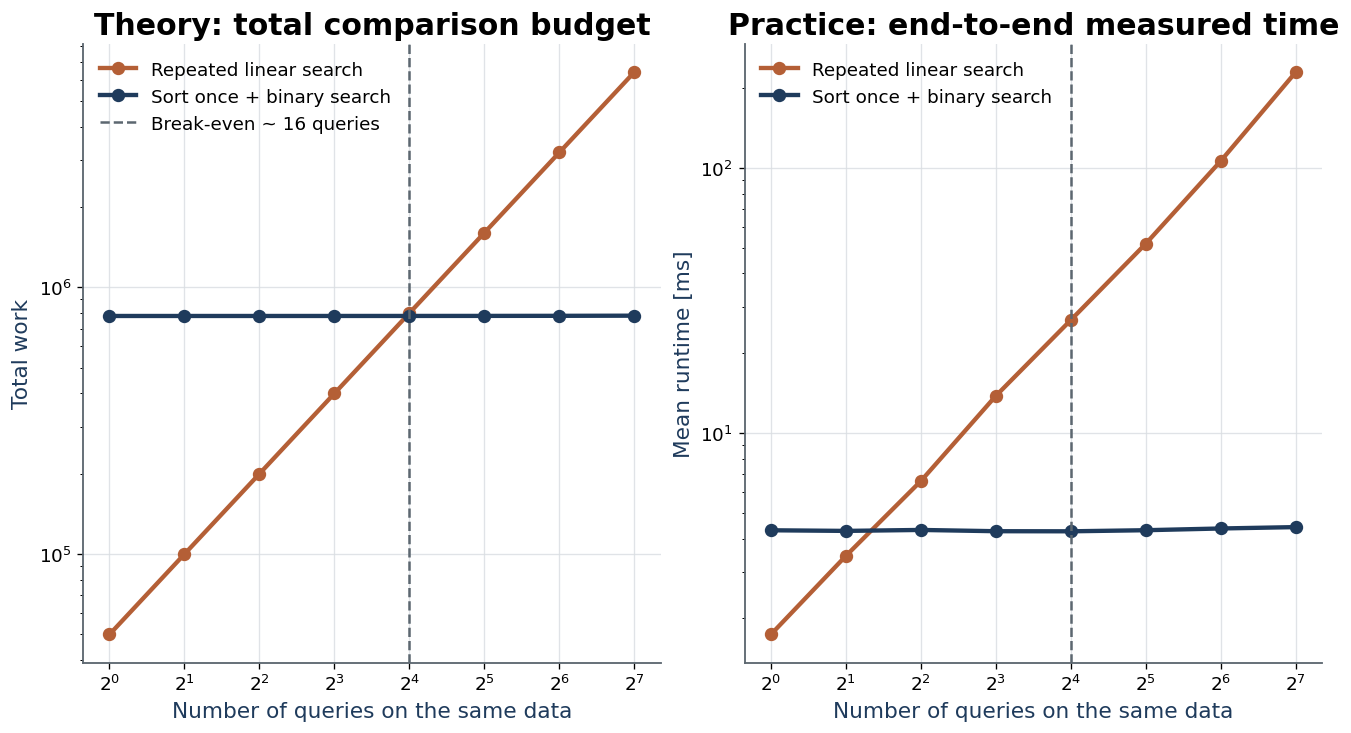

In [17]:
system_data = rng.permutation(system_n).tolist()
system_target = -1

# A coarse theory model for repeated queries.
estimated_sort_cost = system_n * math.log2(system_n)
estimated_binary_cost = math.ceil(math.log2(system_n))
break_even_queries = math.ceil(
    estimated_sort_cost / (system_n - estimated_binary_cost)
)

preprocessing_df = pd.DataFrame(
    {
        'queries': query_counts,
        'linear total comparisons': query_counts * system_n,
        'sort once + binary comparisons': estimated_sort_cost
        + query_counts * estimated_binary_cost,
    }
)

def repeated_linear_queries(query_count):
    """Run query_count independent linear misses on the same unsorted data."""
    for _ in range(int(query_count)):
        linear_search(system_data, system_target)
    return -1

def sort_once_then_binary_queries(query_count):
    """Pay one sorting cost, then reuse the prepared list for all queries."""
    prepared = sorted(system_data)
    for _ in range(int(query_count)):
        binary_search(prepared, system_target)
    return -1

linear_system_timing = time_size_series(repeated_linear_queries, query_counts, repeat=5, warmup=1)
sort_then_search_timing = time_size_series(sort_once_then_binary_queries, query_counts, repeat=5, warmup=1)

preprocessing_story_df = preprocessing_df.copy()
preprocessing_story_df['linear mean ms'] = linear_system_timing['mean_s'] * 1_000
preprocessing_story_df['sort once + binary mean ms'] = sort_then_search_timing['mean_s'] * 1_000
display_wrapped(preprocessing_story_df)

fig, axes = lecture_figure(kind='wide', ncols=2)

axes[0].plot(
    preprocessing_story_df['queries'],
    preprocessing_story_df['linear total comparisons'],
    marker='o',
    label='Repeated linear search',
    color=COLORS['rust'],
)
axes[0].plot(
    preprocessing_story_df['queries'],
    preprocessing_story_df['sort once + binary comparisons'],
    marker='o',
    label='Sort once + binary search',
    color=COLORS['navy'],
)
axes[0].axvline(
    break_even_queries,
    linestyle='--',
    linewidth=1.5,
    color=COLORS['gray'],
    label=f'Break-even ~ {break_even_queries} queries',
)
axes[0].set_xscale('log', base=2)
axes[0].set_yscale('log', base=10)
axes[0].set_title('Theory: total comparison budget')
axes[0].set_xlabel('Number of queries on the same data')
axes[0].set_ylabel('Total work')
axes[0].legend(loc='upper left')

axes[1].plot(
    preprocessing_story_df['queries'],
    preprocessing_story_df['linear mean ms'],
    marker='o',
    label='Repeated linear search',
    color=COLORS['rust'],
)
axes[1].plot(
    preprocessing_story_df['queries'],
    preprocessing_story_df['sort once + binary mean ms'],
    marker='o',
    label='Sort once + binary search',
    color=COLORS['navy'],
)
axes[1].axvline(
    break_even_queries,
    linestyle='--',
    linewidth=1.5,
    color=COLORS['gray'],
)
axes[1].set_xscale('log', base=2)
axes[1].set_yscale('log', base=10)
axes[1].set_title('Practice: end-to-end measured time')
axes[1].set_xlabel('Number of queries on the same data')
axes[1].set_ylabel('Mean runtime [ms]')
axes[1].legend(loc='upper left')

plt.show()


For a single lookup, sorting first is usually wasteful. For many lookups on the same dataset, preprocessing can be the right strategic move.

This is a useful complexity habit: always ask whether you are paying a one-time setup cost or a cost that repeats for every query.


In [21]:
display_wrapped(Markdown(markdown_box(
    'Asymptotic complexity is often a systems story, not just an algorithm story. Data preparation can make a slower-looking method win over repeated use.'
)))

display_wrapped(Markdown(instructor_prompt(
    'Where do you see this tradeoff in practice: indexing a database, building a lookup table, or precomputing simulation data.'
)))


> **Takeaway:**
> Asymptotic complexity is often a systems story, not just an algorithm story. Data preparation can make a slower-looking method win over repeated use.

> **Instructor Prompt:**
> Where do you see this tradeoff in practice: indexing a database, building a lookup table, or precomputing simulation data.

## 5. Recap / takeaways


In [19]:
display_wrapped(Markdown(markdown_box(
    """
    1. Input size n has to be defined carefully. In this notebook it meant list length.
    2. Growth laws that look similar on small examples separate dramatically as n increases.
    3. Operation counts explain the scaling law; timing experiments reveal practical constants and overhead.
    4. Binary search is powerful only after preprocessing makes the data searchable in that way.
    5. Sorting and searching are not isolated tasks: the total workflow matters.
    """,
    title='Recap',
)))


> **Recap:**
> 1. Input size n has to be defined carefully. In this notebook it meant list length.
> 2. Growth laws that look similar on small examples separate dramatically as n increases.
> 3. Operation counts explain the scaling law; timing experiments reveal practical constants and overhead.
> 4. Binary search is powerful only after preprocessing makes the data searchable in that way.
> 5. Sorting and searching are not isolated tasks: the total workflow matters.

## 6. Questions for students / lecture prompts

- If `n` doubles, which of today's growth laws changes the least? Which changes the most?
- When does a simple algorithm still make sense, even if its asymptotic class is worse?
- Why is binary search not a fair comparison against linear search unless we talk about sorted input?
- Can you name a real task where paying a preprocessing cost once is clearly worth it?
- If timing and theory disagree slightly on a laptop, which result should guide your conceptual understanding?
